In [2]:
import pandas as pd
from canexao import connect_to_mongo
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

sns.set_theme(style="whitegrid")

collection_users, collection_tasks = connect_to_mongo()
tabela_users = pd.DataFrame(list(collection_users.find()))
tabela = pd.DataFrame(list(collection_tasks.find()))


Conexão estabelecida com sucesso!


In [3]:
tabela.head()

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,data_conclusao,status_atual,feedback_conclusao_mentorado,createdAt,updatedAt,__v
0,6a2b884993a2aac46c8ba14b,2.0,Testar Scripts de Deploy - Sprint 2,Atividade focada em testar o recurso de script...,alta,6a2b8468cf36b576d237ae6c,Felipe Andrade,QA,Juliana Costa,2026-03-25,2026-03-27,2026-04-02,concluida,Os testes cobriram os cenários críticos de aut...,NaT,NaT,NaN
1,6a2b884993a2aac46c8ba14f,6.0,Documentar Acessibilidade (WCAG) - Sprint 7,Atividade focada em documentar o recurso de ac...,baixa,6a2b84cbcf36b576d237ae6f,Henrique Alves,UX/UIDesigner,Juliana Costa,2026-05-05,2026-05-07,NaT,andamento,NaN,NaT,NaT,NaN
2,6a2b884993a2aac46c8ba150,7.0,Criar API de Login - Sprint 10,Atividade focada em criar o recurso de api de ...,alta,6a2b8445cf36b576d237ae6b,Bruno Costa,DevBack-end,Juliana Costa,2026-05-17,NaT,NaT,pendente,NaN,NaT,NaT,NaN
3,6a2b884993a2aac46c8ba153,10.0,Criar Dashboard - Sprint 1,Atividade focada em criar o recurso de dashboard.,media,6a2b84eecf36b576d237ae71,Eduarda Souza,DevFront-end,Juliana Costa,2026-03-27,2026-03-29,2026-04-09,concluida,Interface montada conforme o protótipo. O dese...,NaT,NaT,NaN
4,6a2b884993a2aac46c8ba15d,20.0,Refatorar Cache em Redis - Sprint 7,Atividade focada em refatorar o recurso de cac...,media,6a2b8445cf36b576d237ae6b,Bruno Costa,DevBack-end,Juliana Costa,2026-03-23,2026-03-25,2026-04-03,concluida,A refatoração limpou chaves redundantes e otim...,NaT,NaT,NaN


In [4]:
# Mostra o número de linhas, colunas e o tipo de dados de cada coluna
tabela.info()

# Mostra um resumo estatístico das colunas numéricas
tabela.describe()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   _id                           77 non-null     object        
 1   task_id                       76 non-null     float64       
 2   titulo                        77 non-null     str           
 3   descricao                     77 non-null     str           
 4   prioridade                    77 non-null     str           
 5   user_id                       77 non-null     object        
 6   mentorado                     77 non-null     str           
 7   area_atuacao                  76 non-null     str           
 8   mentor_responsavel            77 non-null     str           
 9   data_criacao                  76 non-null     datetime64[us]
 10  data_inicio                   63 non-null     datetime64[us]
 11  data_conclusao                44 non-null    

,task_id,data_criacao,data_inicio,data_conclusao,createdAt,updatedAt,__v
count,76.000000,76,63,44,1,1,1.0
mean,38.500000,2026-04-18 14:31:34.736842,2026-04-14 17:54:17.142857,2026-04-12 08:10:54.545454,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
min,1.000000,2026-03-01 00:00:00,2026-03-03 00:00:00,2026-03-09 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
25%,19.750000,2026-03-23 18:00:00,2026-03-23 12:00:00,2026-03-27 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
50%,38.500000,2026-04-28 00:00:00,2026-04-16 00:00:00,2026-04-05 12:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
75%,57.250000,2026-05-12 00:00:00,2026-05-08 12:00:00,2026-04-29 06:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
max,76.000000,2026-05-27 00:00:00,2026-06-11 00:00:00,2026-06-15 00:00:00,2026-06-12 04:33:03.195000,2026-06-12 04:38:14.840000,0.0
std,22.083176,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# 1. Converter as colunas de data de texto para o formato de data real (datetime)
tabela['data_criacao'] = pd.to_datetime(tabela['data_criacao'], errors='coerce')
tabela['data_inicio'] = pd.to_datetime(tabela['data_inicio'], errors='coerce')
tabela['data_conclusao'] = pd.to_datetime(tabela['data_conclusao'], errors='coerce')

# 2. Criar uma coluna útil: Tempo de Resolução (em dias) entre a criação e a conclusão
tabela['tempo_conclusao_dias'] = (tabela['data_conclusao'] - tabela['data_criacao']).dt.days

# Verificando se as transformações deram certo
tabela[['data_criacao', 'data_inicio', 'data_conclusao', 'tempo_conclusao_dias']].info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   data_criacao          76 non-null     datetime64[us]
 1   data_inicio           63 non-null     datetime64[us]
 2   data_conclusao        44 non-null     datetime64[us]
 3   tempo_conclusao_dias  43 non-null     float64       
dtypes: datetime64[us](3), float64(1)
memory usage: 2.5 KB


In [6]:
tabela['tempo_conclusao_dias'].describe()

count    43.000000
mean     12.697674
std       5.307384
min       4.000000
25%       8.000000
50%      12.000000
75%      17.000000
max      23.000000
Name: tempo_conclusao_dias, dtype: float64

In [7]:
# 1. Média de dias para concluir uma tarefa
media_dias = tabela['tempo_conclusao_dias'].mean()
mediana_dias = tabela['tempo_conclusao_dias'].median()
max_dias = tabela['tempo_conclusao_dias'].max()

print(f"⏱️ Tempo Médio de Conclusão: {media_dias:.1f} dias")
print(f"🎯 Mediana do Tempo (50% das tarefas): {mediana_dias:.1f} dias")
print(f"🚨 Tarefa mais demorada levou: {max_dias:.1f} dias")
print("-" * 50)

# 2. Qual área de atuação demora mais para concluir as tarefas?
print("🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:")
print(tabela.groupby('area_atuacao')['tempo_conclusao_dias'].mean().sort_values(ascending=False))
print("-" * 50)

# 3. Qual nível de prioridade está levando mais tempo?
print("⚠️ Tempo médio de conclusão por PRIORIDADE:")
print(tabela.groupby('prioridade')['tempo_conclusao_dias'].mean().sort_values(ascending=False))

⏱️ Tempo Médio de Conclusão: 12.7 dias
🎯 Mediana do Tempo (50% das tarefas): 12.0 dias
🚨 Tarefa mais demorada levou: 23.0 dias
--------------------------------------------------
🐢 Tempo médio de conclusão por ÁREA DE ATUAÇÃO:
area_atuacao
Data Engineer    15.200000
DevBack-end      13.857143
QA               12.500000
UX/UIDesigner    12.000000
DevMobile        10.800000
Produto          10.666667
DevFront-end     10.571429
Name: tempo_conclusao_dias, dtype: float64
--------------------------------------------------
⚠️ Tempo médio de conclusão por PRIORIDADE:
prioridade
media    13.157895
alta     12.533333
baixa    12.000000
Name: tempo_conclusao_dias, dtype: float64


In [8]:
# 1. Distribuição Geral dos Status (Quantidade e Percentual)
print("📊 DISTRIBUIÇÃO GERAL DOS STATUS:")
status_qtd = tabela['status_atual'].value_counts()
status_pct = tabela['status_atual'].value_counts(normalize=True) * 100

for status in status_qtd.index:
    print(f"• {status}: {status_qtd[status]} tarefas ({status_pct[status]:.1f}%)")
print("-" * 50)

# 2. Quais áreas têm mais tarefas que ainda NÃO foram concluídas?
# Filtrando onde a data de conclusão está vazia (NaN)
print("⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:")
pendentes_por_area = tabela[tabela['data_conclusao'].isna()]['area_atuacao'].value_counts()
print(pendentes_por_area)
print("-" * 50)

# 3. Cruzamento: Quem está cuidando de quais status?
print("🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:")
print(pd.crosstab(tabela['mentor_responsavel'], tabela['status_atual']))

📊 DISTRIBUIÇÃO GERAL DOS STATUS:
• concluida: 44 tarefas (57.1%)
• andamento: 19 tarefas (24.7%)
• pendente: 14 tarefas (18.2%)
--------------------------------------------------
⏳ TAREFAS PENDENTES (Não concluídas) POR ÁREA DE ATUAÇÃO:
area_atuacao
QA               9
Data Engineer    6
DevMobile        5
Produto          4
UX/UIDesigner    3
DevBack-end      3
DevFront-end     3
Name: count, dtype: int64
--------------------------------------------------
🤝 STATUS DAS TAREFAS POR MENTOR RESPONSÁVEL:
status_atual        andamento  concluida  pendente
mentor_responsavel                                
Juliana Costa              19         44        14


C:\Users\lmm4\AppData\Local\Temp\ipykernel_11932\3819263364.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")


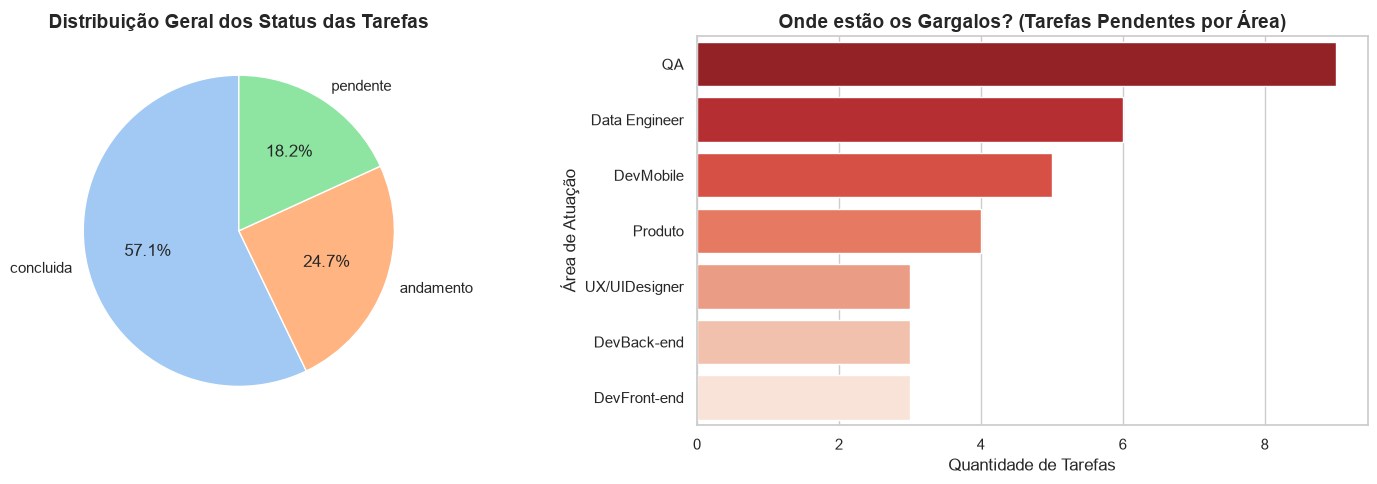

In [9]:


# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Distribuição de Status
plt.subplot(1, 2, 1)
status_cores = sns.color_palette("pastel")[0:3]
plt.pie(status_qtd, labels=status_qtd.index, autopct='%1.1f%%', startangle=90, colors=status_cores)
plt.title("Distribuição Geral dos Status das Tarefas", fontsize=14, fontweight='bold')

# Gráfico 2: Tarefas Pendentes por Área
plt.subplot(1, 2, 2)
sns.barplot(x=pendentes_por_area.values, y=pendentes_por_area.index, palette="danger_r" if "danger_r" in dir(sns.color_palette) else "Reds_r")
plt.title("Onde estão os Gargalos? (Tarefas Pendentes por Área)", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Tarefas")
plt.ylabel("Área de Atuação")

plt.tight_layout()
plt.show()

In [10]:
databcorte = pd.to_datetime('2026-05-31')


tabela['duracao_em_dias'] = np.nan
tabela['tempo_no_backlog'] = np.nan


task_concluida = tabela['status_atual'] == 'concluida'
tabela.loc[task_concluida, 'duracao_em_dias'] = (tabela.loc[task_concluida, 'data_conclusao'] - tabela.loc[task_concluida, 'data_inicio']).dt.days

task_andamento = tabela['status_atual'] == 'andamento'
tabela.loc[task_andamento, 'duracao_em_dias'] = (databcorte - tabela.loc[task_andamento, 'data_inicio']).dt.days

task_pendente = tabela['status_atual'] == 'pendente'
tabela.loc[task_pendente, 'duracao_em_dias'] = (databcorte - tabela.loc[task_pendente, 'data_criacao']).dt.days


tabela['tempo_no_backlog'] = np.where(
    tabela['status_atual'] == 'pendente',
    (databcorte - tabela['data_criacao']).dt.days,
    (tabela['data_inicio'] - tabela['data_criacao']).dt.days
)

print(tabela[['status_atual', 'duracao_em_dias', 'tempo_no_backlog']].head(10))

  status_atual  duracao_em_dias  tempo_no_backlog
0    concluida              6.0               2.0
1    andamento             24.0               2.0
2     pendente             14.0              14.0
3    concluida             11.0               2.0
4    concluida              9.0               2.0
5    concluida             10.0               2.0
6    andamento             12.0               0.0
7     pendente             21.0              21.0
8    concluida              7.0               3.0
9    concluida             14.0               1.0


# MENTORADA(Filtro)



In [11]:
tabela['mentorado'].value_counts()

mentorado
Ana Ribeiro       16
Felipe Andrade    10
Bruno Costa       10
Eduarda Souza     10
Gabriela Pinto    10
Diego Martins      9
Camila Lopes       7
Henrique Alves     4
Milenna Xavier     1
Name: count, dtype: int64

In [12]:
mentorada = tabela[tabela['mentorado'] == 'Ana Ribeiro'].copy()
mentorada.head(16)

,_id,task_id,titulo,descricao,prioridade,user_id,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,data_conclusao,status_atual,feedback_conclusao_mentorado,createdAt,updatedAt,__v,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog
5,6a2b884993a2aac46c8ba15f,22.0,Documentar Tabelas no BD - Sprint 6,Atividade focada em documentar o recurso de ta...,baixa,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-20,2026-03-22,2026-04-01,concluida,Documentação finalizada englobando os esquemas...,NaT,NaT,NaN,12.0,10.0,2.0
7,6a2b884993a2aac46c8ba16e,37.0,Otimizar Pipeline CI/CD - Sprint 2,Atividade focada em otimizar o recurso de pipe...,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-10,NaT,NaT,pendente,NaN,NaT,NaT,NaN,NaN,21.0,21.0
10,6a2b884993a2aac46c8ba17b,50.0,Criar Pipeline CI/CD - Sprint 7,Atividade focada em criar o recurso de pipelin...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-25,2026-05-29,NaT,andamento,NaN,NaT,NaT,NaN,NaN,2.0,4.0
14,6a2b884993a2aac46c8ba190,71.0,Ajustar Pipeline CI/CD - Sprint 2,Atividade focada em ajustar o recurso de pipel...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-22,2026-03-25,2026-04-05,concluida,Ajustamos o isolamento seguro de chaves sensív...,NaT,NaT,NaN,14.0,11.0,3.0
15,6a2b884993a2aac46c8ba191,72.0,Refatorar Pipeline CI/CD - Sprint 7,Atividade focada em refatorar o recurso de pip...,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-03,2026-03-04,2026-03-23,concluida,Removemos etapas de compilação redundantes e r...,NaT,NaT,NaN,20.0,19.0,1.0
19,6a2b884993a2aac46c8ba154,11.0,Atualizar Pipeline CI/CD - Sprint 1,Atividade focada em atualizar o recurso de pip...,media,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-03-04,2026-03-05,2026-03-12,concluida,Otimizamos o tempo total do fluxo de integraçã...,NaT,NaT,NaN,8.0,7.0,1.0
20,6a2b884993a2aac46c8ba157,14.0,Documentar Tabelas no BD - Sprint 4,Atividade focada em documentar o recurso de ta...,baixa,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-15,2026-04-16,2026-05-01,concluida,Dicionário de dados atualizado com sucesso no ...,NaT,NaT,NaN,16.0,15.0,1.0
23,6a2b884993a2aac46c8ba16c,35.0,Implementar Tabelas no BD - Sprint 5,Atividade focada em implementar o recurso de t...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-05-14,NaT,NaT,pendente,NaN,NaT,NaT,NaN,NaN,17.0,17.0
28,6a2b884993a2aac46c8ba17e,53.0,Refatorar Scripts de Deploy - Sprint 5,Atividade focada em refatorar o recurso de scr...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-24,2026-04-27,2026-05-16,concluida,Limpamos as configurações antigas que estavam ...,NaT,NaT,NaN,22.0,19.0,3.0
38,6a2b884993a2aac46c8ba151,8.0,Criar Scripts de Deploy - Sprint 2,Atividade focada em criar o recurso de scripts...,alta,6a2b84ddcf36b576d237ae70,Ana Ribeiro,Data Engineer,Juliana Costa,2026-04-20,2026-04-21,2026-04-30,concluida,Atividade finalizada com sucesso. A automação ...,NaT,NaT,NaN,10.0,9.0,1.0


In [13]:
mentorada.drop(columns=['descricao', 'mentor_responsavel', 'createdAt','updatedAt','__v', '_id','user_id'], inplace=True, errors='ignore')

In [14]:
mentorada.isnull().sum()

task_id                         0
titulo                          0
prioridade                      0
mentorado                       0
area_atuacao                    0
data_criacao                    0
data_inicio                     3
data_conclusao                  6
status_atual                    0
feedback_conclusao_mentorado    6
tempo_conclusao_dias            6
duracao_em_dias                 0
tempo_no_backlog                0
dtype: int64

In [15]:
mentorada.duplicated().sum()

np.int64(0)

In [16]:
mentorada.head(16)

,task_id,titulo,prioridade,mentorado,area_atuacao,data_criacao,data_inicio,data_conclusao,status_atual,feedback_conclusao_mentorado,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog
5,22.0,Documentar Tabelas no BD - Sprint 6,baixa,Ana Ribeiro,Data Engineer,2026-03-20,2026-03-22,2026-04-01,concluida,Documentação finalizada englobando os esquemas...,12.0,10.0,2.0
7,37.0,Otimizar Pipeline CI/CD - Sprint 2,media,Ana Ribeiro,Data Engineer,2026-05-10,NaT,NaT,pendente,NaN,NaN,21.0,21.0
10,50.0,Criar Pipeline CI/CD - Sprint 7,alta,Ana Ribeiro,Data Engineer,2026-05-25,2026-05-29,NaT,andamento,NaN,NaN,2.0,4.0
14,71.0,Ajustar Pipeline CI/CD - Sprint 2,alta,Ana Ribeiro,Data Engineer,2026-03-22,2026-03-25,2026-04-05,concluida,Ajustamos o isolamento seguro de chaves sensív...,14.0,11.0,3.0
15,72.0,Refatorar Pipeline CI/CD - Sprint 7,media,Ana Ribeiro,Data Engineer,2026-03-03,2026-03-04,2026-03-23,concluida,Removemos etapas de compilação redundantes e r...,20.0,19.0,1.0
19,11.0,Atualizar Pipeline CI/CD - Sprint 1,media,Ana Ribeiro,Data Engineer,2026-03-04,2026-03-05,2026-03-12,concluida,Otimizamos o tempo total do fluxo de integraçã...,8.0,7.0,1.0
20,14.0,Documentar Tabelas no BD - Sprint 4,baixa,Ana Ribeiro,Data Engineer,2026-04-15,2026-04-16,2026-05-01,concluida,Dicionário de dados atualizado com sucesso no ...,16.0,15.0,1.0
23,35.0,Implementar Tabelas no BD - Sprint 5,alta,Ana Ribeiro,Data Engineer,2026-05-14,NaT,NaT,pendente,NaN,NaN,17.0,17.0
28,53.0,Refatorar Scripts de Deploy - Sprint 5,alta,Ana Ribeiro,Data Engineer,2026-04-24,2026-04-27,2026-05-16,concluida,Limpamos as configurações antigas que estavam ...,22.0,19.0,3.0
38,8.0,Criar Scripts de Deploy - Sprint 2,alta,Ana Ribeiro,Data Engineer,2026-04-20,2026-04-21,2026-04-30,concluida,Atividade finalizada com sucesso. A automação ...,10.0,9.0,1.0


In [17]:
mentorada.info()

<class 'pandas.DataFrame'>
Index: 16 entries, 5 to 71
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   task_id                       16 non-null     float64       
 1   titulo                        16 non-null     str           
 2   prioridade                    16 non-null     str           
 3   mentorado                     16 non-null     str           
 4   area_atuacao                  16 non-null     str           
 5   data_criacao                  16 non-null     datetime64[us]
 6   data_inicio                   13 non-null     datetime64[us]
 7   data_conclusao                10 non-null     datetime64[us]
 8   status_atual                  16 non-null     str           
 9   feedback_conclusao_mentorado  10 non-null     str           
 10  tempo_conclusao_dias          10 non-null     float64       
 11  duracao_em_dias               16 non-null     floa

# EDA -MENTORADA



In [18]:
concluidas_ment = mentorada[mentorada['status_atual'] == 'concluida']
andamento_ment = mentorada[mentorada['status_atual'] == 'andamento']
pendentes_ment = mentorada[mentorada['status_atual'] == 'pendente']

print("\n--- DURAÇÃO EM DIAS (MÉDIAS) ---")
print(f"Média Conclusão: {concluidas_ment['duracao_em_dias'].mean().round(1)} dias")
print(f"Média Em Andamento (dias rodando): {andamento_ment['duracao_em_dias'].mean().round(1)} dias")
print(f"Média Pendente (dias parada): {pendentes_ment['duracao_em_dias'].mean().round(1)} dias")

print("\n--- TEMPO NO BACKLOG (MÉDIAS) ---")
print(f"Tempo no Backlog (Concluídas): {concluidas_ment['tempo_no_backlog'].mean().round(1)} dias")
print(f"Tempo no Backlog (Em Andamento): {andamento_ment['tempo_no_backlog'].mean().round(1)} dias")
print(f"Tempo no Backlog (Pendentes): {pendentes_ment['tempo_no_backlog'].mean().round(1)} dias")


--- DURAÇÃO EM DIAS (MÉDIAS) ---
Média Conclusão: 13.2 dias
Média Em Andamento (dias rodando): 7.0 dias
Média Pendente (dias parada): 14.0 dias

--- TEMPO NO BACKLOG (MÉDIAS) ---
Tempo no Backlog (Concluídas): 2.0 dias
Tempo no Backlog (Em Andamento): 3.3 dias
Tempo no Backlog (Pendentes): 14.0 dias


In [19]:
status_contagem = mentorada['status_atual'].value_counts()
status_percentual = (mentorada['status_atual'].value_counts(normalize=True) * 100).round(1)


df_status = pd.DataFrame({'Quantidade': status_contagem, 'Percentual (%)': status_percentual})
display(df_status)



,Quantidade,Percentual (%)
status_atual,,
concluida,10,62.5
pendente,3,18.8
andamento,3,18.8


In [20]:
media_por_prioridade = mentorada.groupby('prioridade')['duracao_em_dias'].mean().round(1)
print( f'A média de dias por prioridade é: {media_por_prioridade}')

mediana_por_prioridade = mentorada.groupby('prioridade')['duracao_em_dias'].median().round(1)
print(f'A mediana de dias por prioridade é: {mediana_por_prioridade}')

A média de dias por prioridade é: prioridade
alta     11.2
baixa    12.5
media    15.7
Name: duracao_em_dias, dtype: float64
A mediana de dias por prioridade é: prioridade
alta     11.0
baixa    12.5
media    19.0
Name: duracao_em_dias, dtype: float64


In [21]:
mentorada.describe()

,task_id,data_criacao,data_inicio,data_conclusao,tempo_conclusao_dias,duracao_em_dias,tempo_no_backlog
count,16.000000,16,13,10,10.000000,16.000000,16.000000
mean,37.062500,2026-04-19 09:00:00,2026-04-15 07:23:04.615384,2026-04-16 21:36:00,15.200000,12.187500,4.500000
min,8.000000,2026-03-03 00:00:00,2026-03-04 00:00:00,2026-03-12 00:00:00,8.000000,2.000000,1.000000
25%,17.250000,2026-03-21 12:00:00,2026-03-22 00:00:00,2026-03-25 06:00:00,10.500000,6.500000,1.000000
50%,33.500000,2026-04-22 12:00:00,2026-04-21 00:00:00,2026-04-17 12:00:00,15.000000,12.500000,3.000000
75%,54.000000,2026-05-12 12:00:00,2026-05-11 00:00:00,2026-05-07 18:00:00,19.750000,17.500000,4.000000
max,72.000000,2026-05-27 00:00:00,2026-05-29 00:00:00,2026-05-31 00:00:00,23.000000,21.000000,21.000000
std,22.040777,NaN,NaN,NaN,5.652925,6.358393,5.842374


In [22]:
Q1 = mentorada['duracao_em_dias'].quantile(0.25)
Q3 = mentorada['duracao_em_dias'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

print(f"\nLimite Superior de dias normais: {limite_superior}")


Limite Superior de dias normais: 34.0


In [23]:
historico = tabela[tabela['status_atual'] == 'concluida']
mediana_geral_por_prioridade = historico.groupby('prioridade')['duracao_em_dias'].median().round(1) 

# mapear pela mediana visando uma avaliação mais realista, já que a média pode ser distorcida por outliers (tarefas que demoraram muito mais do que o normal). A mediana nos dá uma visão mais robusta do tempo típico de conclusão para cada prioridade.
tarefas_n_concluida = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()
tarefas_n_concluida['tempo_limite'] = tarefas_n_concluida['prioridade'].map(mediana_geral_por_prioridade) 

print("\n--- AVALIAÇÃO DE GARGALO FUTURO ---")
display(tarefas_n_concluida[['titulo', 'status_atual', 'prioridade', 'duracao_em_dias', 'tempo_limite']])


--- AVALIAÇÃO DE GARGALO FUTURO ---


,titulo,status_atual,prioridade,duracao_em_dias,tempo_limite
7,Otimizar Pipeline CI/CD - Sprint 2,pendente,media,21.0,11.0
10,Criar Pipeline CI/CD - Sprint 7,andamento,alta,2.0,8.5
23,Implementar Tabelas no BD - Sprint 5,pendente,alta,17.0,8.5
53,Atualizar Scripts de Deploy - Sprint 9,andamento,alta,5.0,8.5
58,Implementar Scripts de Deploy - Sprint 1,andamento,alta,14.0,8.5
71,Otimizar Scripts de Deploy - Sprint 8,pendente,alta,4.0,8.5


# KPIs


##card - valores totais, médias gerais, ou algo muito expecidfico

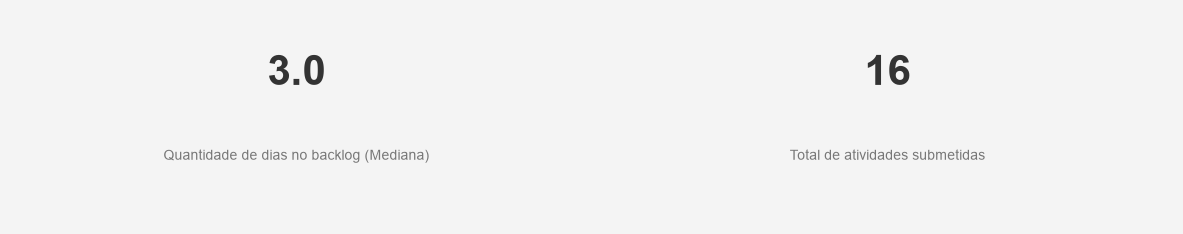

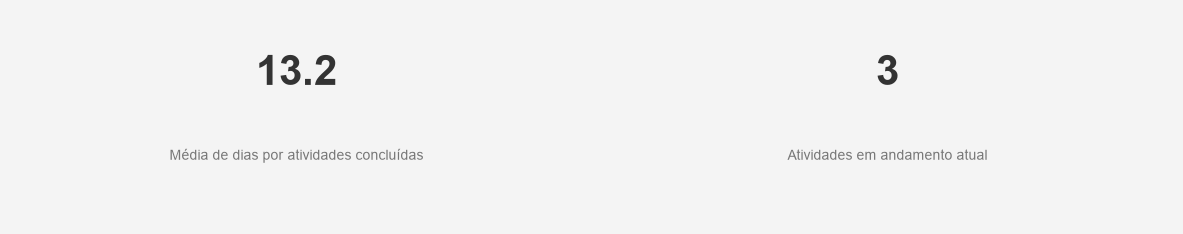

In [24]:
totalatividades = mentorada['status_atual'].count()
medianaconclusao = mentorada['tempo_no_backlog'].median()
mediaconclusao = mentorada[mentorada['status_atual'] == 'concluida']['duracao_em_dias'].mean().round(1)
TotalAtvAndamento = len(mentorada[mentorada['status_atual'] == 'andamento'])

# Plotagem dos Cards 1 e 2 (Backlog e Total)
fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
fig.patch.set_facecolor('#f4f4f4')

for ax, valor, texto in zip(axes, [medianaconclusao, totalatividades], 
                             ['Quantidade de dias no backlog (Mediana)', 'Total de atividades submetidas']):
    ax.patch.set_facecolor('#f4f4f4')
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.text(0.5, 0.65, str(valor), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
    ax.text(0.5, 0.30, texto, fontsize=10, ha='center', color='#777777', transform=ax.transAxes)

plt.tight_layout()
plt.show()

# Plotagem dos Cards 3 e 4 (Tempo Médio de Entrega e WIP)
fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
fig.patch.set_facecolor('#f4f4f4')

for ax, valor, texto in zip(axes, [mediaconclusao, TotalAtvAndamento], 
                             ['Média de dias por atividades concluídas', 'Atividades em andamento atual']):
    ax.patch.set_facecolor('#f4f4f4')
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    ax.text(0.5, 0.65, str(valor), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
    ax.text(0.5, 0.30, texto, fontsize=10, ha='center', color='#777777', transform=ax.transAxes)

plt.tight_layout()
plt.show()

## PIZZA GRAFICO



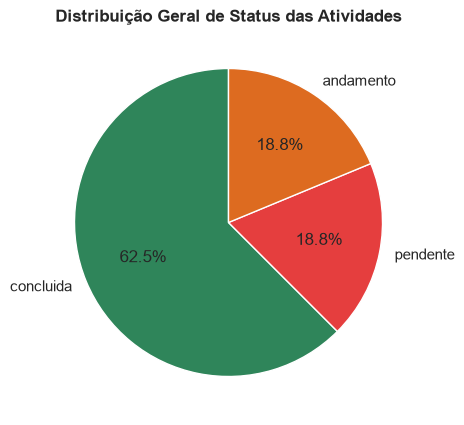

In [33]:

status_andamento = mentorada['status_atual'].value_counts()

cores_status = {
    'concluida': '#2f855a',  # Verde
    'andamento': '#dd6b20',  # Laranja
    'pendente': '#e53e3e'   # Vermelho
}
lista_cores = [cores_status[status] for status in status_andamento.index]


plt.figure(figsize=(5, 5))
plt.pie(status_andamento, labels=status_andamento.index, autopct='%1.1f%%', colors=lista_cores, startangle=90)
plt.title('Distribuição Geral de Status das Atividades', fontsize=12, fontweight='bold')
plt.savefig('grafico_status.png', transparent=True)
plt.show()

GRAFICO DINAMICO

In [35]:
# o grafico grande que é aO GRAFICO DE ANA Q MOSTRA AS ENTREGAS AO LONGO DAS SPRINGS.

#base ado nos dados gerais de todos os mentorados
concluidas_equipe = tabela[tabela['status_atual'] == 'concluida']
media_equipe = concluidas_equipe['duracao_em_dias'].mean()
teto_do_grafico = concluidas_equipe['duracao_em_dias'].max() + 2

# 2. pra cada atividade
mapa_de_cores = {
    'alta': '#E74C3C',    # Vermelho Alerta
    'Alta': '#E74C3C',
    'média': '#F39C12',   # Laranja/Amarelo Atenção
    'media': '#F39C12',
    'Média': '#F39C12',
    'baixa': '#2ECC71',   # Verde Tranquilo
    'Baixa': '#2ECC71'
}


def criar_grafico_evolucao(dataset_alvo, titulo_do_grafico):
    df_plot = dataset_alvo[dataset_alvo['status_atual'] == 'concluida'].copy()
    if df_plot.empty:
        print("Nenhuma tarefa concluída para plotar no gráfico de evolução.")
        return None
        
    df_plot['sprint_num'] = df_plot['titulo'].str.extract(r'Sprint (\d+)').fillna(0).astype(int)
    df_plot['nome_sprint'] = df_plot['titulo'].str.extract(r'(Sprint \d+)').fillna('Sem Sprint')
    df_plot = df_plot.sort_values('sprint_num')

    fig = px.scatter(
        df_plot, x='nome_sprint', y='duracao_em_dias', color='prioridade',
        color_discrete_map=mapa_de_cores, hover_data=['titulo', 'mentorado'],
        title=titulo_do_grafico,
        labels={'duracao_em_dias': 'Dias Gastos', 'nome_sprint': 'Sprint', 'prioridade': 'Dificuldade'}
    )
    fig.add_hline(y=media_equipe, line_dash="dash", line_color="gray",
                  annotation_text=f"Média Geral ({media_equipe:.1f} dias)", annotation_position="bottom right")
    fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    fig.update_yaxes(range=[0, teto_do_grafico])
    return fig

grafico_ana = criar_grafico_evolucao(mentorada, "Evolução Individual X Média da Equipe")
if grafico_ana: grafico_ana.show()

##Tabela

In [29]:

#usar o historico de entregas de todos os mentorados para ter um parametro de atividade dos mentorados atravez das
historico_geral = tabela[tabela['status_atual'] == 'concluida']
media_por_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].mean().round(1)

tabela_ativas_ana = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()

# Injetamos a meta na tabela da Ana cruzando a prioridade
mentorada['meta_dias'] = mentorada['prioridade'].map(media_por_prioridade)

def sinalizar_status_real(linha): #verificação linha por linha do pandas para chegar nos resultados
    dias = linha['duracao_em_dias'] #mostra há quantos dias aquela atividade está rolando (desde que foi criada ou iniciada até a nossa data de corte).
    meta = linha['meta_dias'] #usar a coluna correta 'meta_dias'

    if linha['status_atual'] == 'pendente':
        return '🔴 Crítico (Fila)' if dias > 10 else '⚪ Pendente Normal'

    elif linha['status_atual'] == 'andamento':
        if dias > (meta * 2):
            return '🔴 Crítico'
        elif dias > meta:
            return '🟡 Atrasado'
        else:
            # Adicionado para tarefas em 'andamento' mas 'Dentro do Prazo'
            return '🟢 Dentro do Prazo'
    else:
        # Adicionado para tarefas 'concluida' que não tinham retorno
        return '✔️ Entregue'
mentorada['Diagnostico'] = mentorada.apply(sinalizar_status_real, axis=1)
mentorada['dias_de_atraso'] = mentorada['duracao_em_dias'] - mentorada['meta_dias']

atvd_ativa_ = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()
tabela_completa_ana = atvd_ativa_[[
    'titulo', 'mentorado', 'prioridade', 'status_atual',
    'duracao_em_dias', 'meta_dias', 'dias_de_atraso', 'Diagnostico'
]].sort_values(by='dias_de_atraso', ascending=False)




condicao_problema_ana = tabela_completa_ana['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas_ana = tabela_completa_ana[condicao_problema_ana].drop(columns=['dias_de_atraso'])


print("=== TABELA DE visualização de atividades não entregues) ===")
display(tabela_problemas_ana)


=== TABELA DE visualização de atividades não entregues) ===


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
7,Otimizar Pipeline CI/CD - Sprint 2,Ana Ribeiro,media,pendente,21.0,11.4,🔴 Crítico (Fila)
23,Implementar Tabelas no BD - Sprint 5,Ana Ribeiro,alta,pendente,17.0,9.9,🔴 Crítico (Fila)
58,Implementar Scripts de Deploy - Sprint 1,Ana Ribeiro,alta,andamento,14.0,9.9,🟡 Atrasado


In [30]:
# 2. TABELA DE FLUXO NORMAL (Apenas 🟢 Prazo e ⚪ Fila Normal)
condicao_saudavel_ana = tabela_completa_ana['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis_ana = tabela_completa_ana[condicao_saudavel_ana].drop(columns=['dias_de_atraso'])


display(tabela_saudaveis_ana)


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
53,Atualizar Scripts de Deploy - Sprint 9,Ana Ribeiro,alta,andamento,5.0,9.9,🟢 Dentro do Prazo
71,Otimizar Scripts de Deploy - Sprint 8,Ana Ribeiro,alta,pendente,4.0,9.9,⚪ Pendente Normal
10,Criar Pipeline CI/CD - Sprint 7,Ana Ribeiro,alta,andamento,2.0,9.9,🟢 Dentro do Prazo


TABELA PARA VISUALIZAR OS SALDOS DE TODOS OS MENTORADOS E SUAS ATIVIDADES Q ESTAO FORA DA

In [31]:

#tabela geral
historico_geral = tabela[tabela['status_atual'] == 'concluida']
media_por_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].mean().round(1)

tabela_ativas_ana = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()

# Injetamos a meta na tabela tabela cruzando a prioridade
tabela['meta_dias'] = tabela['prioridade'].map(media_por_prioridade)

def sinalizar_status_real(linha):
    dias = linha['duracao_em_dias']
    meta = linha['meta_dias']

    if linha['status_atual'] == 'pendente':
        return '🔴 Crítico (Fila)' if dias > 10 else '⚪ Pendente Normal'

    elif linha['status_atual'] == 'andamento':
        if dias > (meta * 2):
            return '🔴 Crítico'
        elif dias > meta:
            return '🟡 Atrasado'
        else:
            # Adicionado para tarefas em 'andamento' mas 'Dentro do Prazo'
            return '🟢 Dentro do Prazo'
    else:
        # Adicionado para tarefas 'concluida' que não tinham retorno
        return '✔️ Entregue'

tabela['Diagnostico'] = tabela.apply(sinalizar_status_real, axis=1)
tabela['dias_de_atraso'] = tabela['duracao_em_dias'] - tabela['meta_dias']

# Pegamos apenas quem NÃO está concluído
tabela_ativas = tabela[tabela['status_atual'].isin(['andamento', 'pendente'])].copy()


tabela_completa = tabela_ativas[[
    'titulo', 'mentorado', 'prioridade', 'status_atual',
    'duracao_em_dias', 'meta_dias', 'dias_de_atraso', 'Diagnostico'
]].sort_values(by='dias_de_atraso', ascending=False)


#fazer o filtro para não mostrar nada que esteja ok, entregue ou no prazo
condicao_problema = tabela_completa['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas = tabela_completa[condicao_problema].drop(columns=['dias_de_atraso'])


print("=== TABELA DE verificação de tividades não entregues")
display(tabela_problemas)


=== TABELA DE verificação de tividades não entregues


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
69,Testar Fluxo de Autenticação - Sprint 3,Felipe Andrade,alta,andamento,24.0,9.9,🔴 Crítico
1,Documentar Acessibilidade (WCAG) - Sprint 7,Henrique Alves,baixa,andamento,24.0,10.2,🔴 Crítico
26,Testar Scripts de Deploy - Sprint 2,Diego Martins,alta,andamento,23.0,9.9,🔴 Crítico
39,Atualizar Acessibilidade (WCAG) - Sprint 1,Henrique Alves,media,andamento,24.0,11.4,🔴 Crítico
17,Otimizar Microsserviços - Sprint 8,Bruno Costa,media,andamento,24.0,11.4,🔴 Crítico
31,Implementar Fluxo de Autenticação - Sprint 10,Gabriela Pinto,alta,andamento,22.0,9.9,🔴 Crítico
67,Testar Componentes React - Sprint 9,Diego Martins,media,andamento,23.0,11.4,🔴 Crítico
43,Testar Scripts de Deploy - Sprint 2,Felipe Andrade,alta,andamento,20.0,9.9,🔴 Crítico
27,Analisar Pipeline CI/CD - Sprint 2,Felipe Andrade,baixa,pendente,20.0,10.2,🔴 Crítico (Fila)
7,Otimizar Pipeline CI/CD - Sprint 2,Ana Ribeiro,media,pendente,21.0,11.4,🔴 Crítico (Fila)


In [32]:
# 2. TABELA DE FLUXO NORMAL (Apenas 🟢 Prazo e ⚪ Fila Normal)
condicao_saudavel = tabela_completa['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis = tabela_completa[condicao_saudavel].drop(columns=['dias_de_atraso'])

print("\n=== ✅ FLUXO NORMAL (TUDO SOB CONTROLE) ===")
display(tabela_saudaveis)


=== ✅ FLUXO NORMAL (TUDO SOB CONTROLE) ===


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
51,Atualizar Exportação de Relatórios - Sprint 1,Camila Lopes,media,andamento,9.0,11.4,🟢 Dentro do Prazo
50,Implementar Fluxo de Autenticação - Sprint 1,Gabriela Pinto,alta,andamento,6.0,9.9,🟢 Dentro do Prazo
44,Criar API de Login - Sprint 2,Bruno Costa,alta,pendente,5.0,9.9,⚪ Pendente Normal
53,Atualizar Scripts de Deploy - Sprint 9,Ana Ribeiro,alta,andamento,5.0,9.9,🟢 Dentro do Prazo
41,Documentar Exportação de Relatórios - Sprint 9,Camila Lopes,baixa,pendente,5.0,10.2,⚪ Pendente Normal
30,Analisar Microsserviços - Sprint 6,Diego Martins,baixa,pendente,5.0,10.2,⚪ Pendente Normal
71,Otimizar Scripts de Deploy - Sprint 8,Ana Ribeiro,alta,pendente,4.0,9.9,⚪ Pendente Normal
22,Implementar Filtros de Busca - Sprint 3,Gabriela Pinto,alta,pendente,4.0,9.9,⚪ Pendente Normal
48,Testar Pipeline CI/CD - Sprint 4,Diego Martins,media,pendente,4.0,11.4,⚪ Pendente Normal
10,Criar Pipeline CI/CD - Sprint 7,Ana Ribeiro,alta,andamento,2.0,9.9,🟢 Dentro do Prazo


In [38]:
import json

dashboard_data = {}


# SEÇÃO 1: METRICAS MACRO (EQUIPE GERAL)

dashboard_data['visao_geral_equipe'] = {
    "cards": {
        "tempo_medio_execucao_geral_dias": float(tabela['duracao_em_dias'].mean().round(1)),
        "mediana_tempo_geral_dias": float(tabela['duracao_em_dias'].median().round(1)),
        "tarefa_mais_demorada_equipe_dias": float(tabela['duracao_em_dias'].max().round(1))
    },
    "grafico_pizza_status_geral": [
        {
            "status": status,
            "quantidade": int(qtd),
            "percentual": float(pct)
        }
        for status, qtd, pct in zip(status_qtd.index, status_qtd.values, status_pct.values)
    ],
    "grafico_gargalos_por_area": [
        {
            "area": area,
            "quantidade_tarefas_ativas": int(qtd)
        }
        for area, qtd in zip(pendentes_por_area.index, pendentes_por_area.values)
    ],
    "tabela_mentores_status": [
        {
            "mentor": mentor,
            "status_tarefas": linha.to_dict()
        }
        for mentor, linha in pd.crosstab(tabela['mentor_responsavel'], tabela['status_atual']).iterrows()
    ]
}


# SEÇÃO 2: METRICAS MICRO (ANA RIBEIRO)

# RECONSTRUIR df_plot (usado no JSON) a partir dos dados da mentorada
df_plot = mentorada[mentorada['status_atual'] == 'concluida'].copy()
if not df_plot.empty:
    df_plot['sprint_num'] = df_plot['titulo'].str.extract(r'Sprint (\d+)').fillna(0).astype(int)
    df_plot['nome_sprint'] = df_plot['titulo'].str.extract(r'(Sprint \d+)').fillna('Sem Sprint')
    df_plot = df_plot.sort_values('sprint_num')

# garantir série de percentuais alinhada com status_andamento
status_pct = (status_andamento / status_andamento.sum() * 100).round(1)

dashboard_data['visao_individual_mentorada'] = {
    "cards": {
        "tempo_backlog_mediana_dias": float(medianaconclusao),
        "total_atividades_submetidas": int(totalatividades),
        "tempo_medio_conclusao_dias": float(mediaconclusao),
        "atividades_em_andamento_atual": int(TotalAtvAndamento)
    },
    "grafico_pizza_status": [
        {
            "status": status,
            "quantidade": int(qtd),
            "percentual": float(pct),
            "cor_sugerida": "#2f855a" if status == 'concluida' else ("#dd6b20" if status == 'andamento' else "#e53e3e")
        }
        for status, qtd, pct in zip(status_andamento.index, status_andamento.values, status_pct.values)
    ],
    "grafico_evolucao_sprints": {
        "media_geral_equipe_dias": float(round(media_equipe, 1)) if 'media_equipe' in globals() else None,
        "pontos_grafico": [
            {
                "titulo_tarefa": str(linha['titulo']),
                "sprint": str(linha.get('nome_sprint', 'Sem Sprint')),
                "dias_gastos": float(linha['duracao_em_dias']),
                "prioridade": str(linha['prioridade'])
            }
            for _, linha in df_plot.iterrows()
        ] if not df_plot.empty else []
    },
    "tabela_atividades_criticas": tabela_problemas_ana.reset_index().to_dict(orient='records'),
    "tabela_atividades_saudaveis": tabela_saudaveis_ana.reset_index().to_dict(orient='records')
}

# SALVAR ARQUIVO JSON FILTRADO E UNIFICADO

nome_arquivo_json = 'dashboard_sistema_mentoria.json'

with open(nome_arquivo_json, 'w', encoding='utf-8') as f:
    json.dump(dashboard_data, f, indent=4, ensure_ascii=False)

print(f"✅ Arquivo json'{nome_arquivo_json}' gerado com sucesso!")
print("As visões da Equipe Geral e da Ana Ribeiro foram estruturadas no mesmo arquivo para o Front-End.")

✅ Arquivo json'dashboard_sistema_mentoria.json' gerado com sucesso!
As visões da Equipe Geral e da Ana Ribeiro foram estruturadas no mesmo arquivo para o Front-End.


In [39]:
analise_geral_limpa = tabela.to_csv('analise_geral_limpa.csv', index=False)
print("✅ Arquivo 'analise_geral_limpa.csv' gerado com sucesso!")

✅ Arquivo 'analise_geral_limpa.csv' gerado com sucesso!
